In [ ]:
!pip install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.3/366.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import torch
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import DPOTrainer, DPOConfig

In [ ]:
if not os.path.exists("./qwen1.5-1.8b-dpo-lora"):
    os.makedirs("./qwen1.5-1.8b-dpo-lora")
if not os.path.exists("./qwen1.5-1.8b-dpo-lora_training_output"):
    os.makedirs("./qwen1.5-1.8b-dpo-lora_training_output")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
# Step 1: Define your formatting function (output ONLY prompt, chosen, rejected)
def formatdata(data):
    # Construct the prompt by including the contradiction context and the conversation history
    prompt = f"""
    Your objective is to generate a relevant and coherent response to the last user message in the provided conversation history.
    A contradiction was identified between the current preference:

    "{data['Contradiction']['curr_pref']}"
    and the previous preference:

    "{data['Contradiction']['prev_pref']}"
    ```.

    The conversation history is a list of Python dictionaries. Each dictionary contains the following keys: `"turn_id"`, `"speaker"`, and `"text"`.

    Conversation History:
    {data['Conversation']}

    Generate your response as a single Python string.

    The contradiction type is available at:
    "{data['Contradiction']['type']}"

    Below are the types of preference contradiction. For each type, we provide a small illustrative conversation snippet, the agent’s chain-of-thought (reasoning), and an example of the final agent response. You can use these patterns to guide how you compose your own chain-of-thought and response when encountering similar cases.

    ---

    **1. contextual**
    The same preference changes depending on situational context.

    - **Example Conversation:**
      ```
      {
        {"turn_id": 1, "speaker": "user", "text": "I usually love spicy food."},
        {"turn_id": 2, "speaker": "agent", "text": "Great! I can suggest some spicy dishes for you."},
        {"turn_id": 3, "speaker": "user", "text": "Actually, today I’m feeling really tired and my stomach hurts."},
        {"turn_id": 4, "speaker": "agent", "text": "…"},
      }
    Prev_pref: "I usually love spicy food."

    Curr_pref: "Actually, today I’m feeling really tired and my stomach hurts." (implying they don’t want spicy food today)

    Agent’s Chain-of-Thought:

    The user said they love spicy food generally.

    Now they mention “today I’m feeling tired and my stomach hurts,” which implies they don’t want anything spicy right now.

    This is a temporary, context-driven change (health context).

    I should acknowledge their current condition, override the usual preference, and suggest something milder.

    Agent’s Response (as a Python string):

    "I understand—you’re not feeling well today, so spicy food might upset your stomach. How about a gentle chicken broth or plain rice? Let me know if that sounds better."
    2. trade-off
    User holds two preferences that are often incompatible.

    Example Conversation:

    {
      {"turn_id": 1, "speaker": "user", "text": "I want very brief answers."},
      {"turn_id": 2, "speaker": "agent", "text": "Sure—I'll keep it short."},
      {"turn_id": 3, "speaker": "user", "text": "Actually, can you give me more details? I didn’t understand the last explanation."},
      {"turn_id": 4, "speaker": "agent", "text": "…"},
    }
    Prev_pref: "I want very brief answers."

    Curr_pref: "Actually, can you give me more details? I didn’t understand the last explanation."

    Agent’s Chain-of-Thought:

    Previously, the user asked for very brief answers (brevity).

    Now the user says they need more details because they didn’t understand—this conflicts with brevity.

    This is a classic trade-off between “short vs. detailed.”

    I need to balance these: the user values brevity but also clarity. Right now, clarity is more important.

    Agent’s Response (as a Python string):

    "Got it. I’ll give a more detailed explanation this time. Here’s a step-by-step breakdown: …"
    3. topic-Specific
    User’s preference applies only to a particular topic or task.

    Example Conversation:

    {
      {"turn_id": 1, "speaker": "user", "text": "For coding questions, keep answers short."},
      {"turn_id": 2, "speaker": "agent", "text": "Understood—short code replies for coding."},
      {"turn_id": 3, "speaker": "user", "text": "But when it comes to career advice, please elaborate more."},
      {"turn_id": 4, "speaker": "agent", "text": "…"},
    }
    Prev_pref: "For coding questions, keep answers short."

    Curr_pref: "But when it comes to career advice, please elaborate more."

    Agent’s Chain-of-Thought:

    The user set a short-answer rule for coding topics.

    Then they ask for elaboration specifically on career advice.

    These are not contradictory globally—each applies to a different domain.

    I should scope my response: be brief on coding but detailed on career advice.

    Agent’s Response (as a Python string):

    "Understood. Since this is career advice, I’ll provide more detail: To improve your resume, start by highlighting your most relevant projects…"
    4. temporal
    User’s preference has changed over time, not due to immediate context but because their opinion has evolved.

    Example Conversation:

    {
      {"turn_id": 1, "speaker": "user", "text": "I love watching horror movies."},
      {"turn_id": 2, "speaker": "agent", "text": "Horror it is—any favorites?"},
      {"turn_id": 3, "speaker": "user", "text": "I don’t like horror anymore; they stress me out."},
      {"turn_id": 4, "speaker": "agent", "text": "…"},
    }
    Prev_pref: "I love watching horror movies."

    Curr_pref: "I don’t like horror anymore; they stress me out."

    Agent’s Chain-of-Thought:

    The user used to enjoy horror movies.

    Now they explicitly say they don’t like horror anymore (changed over time).

    This is not tied to context (like being sick)—it’s a lasting change in taste.

    I should acknowledge their new preference, deprioritize horror, and perhaps recommend other genres.

    Agent’s Response (as a Python string):

    "I understand that your taste has changed. How about a thriller or a drama instead? Those tend to be suspenseful but less intense than horror."
    5. ambiguous
    User expresses a preference in unclear or hedged language.

    Example Conversation:

    {
      {"turn_id": 1, "speaker": "user", "text": "I kind of like quick replies."},
      {"turn_id": 2, "speaker": "agent", "text": "Okay, I’ll try to reply quickly."},
      {"turn_id": 3, "speaker": "user", "text": "But sometimes I prefer depth over speed."},
      {"turn_id": 4, "speaker": "agent", "text": "…"},}

    Prev_pref: "I kind of like quick replies."

    Curr_pref: "But sometimes I prefer depth over speed."

    Agent’s Chain-of-Thought:

    The user hedges: “I kind of like quick replies,” not a firm command.

    Then they clarify: “Sometimes I prefer depth.”

    This signals uncertainty—we can’t be sure whether to always be fast or sometimes slow.

    I should ask a clarifying question about which style they want for the current question, while modeling “confidence weight.”

    Agent’s Response (as a Python string):

    "Got it. Would you like me to focus on a quick answer right now, or do you need more in-depth detail? Let me know which you’d prefer for this question."
    6. meta
    User expresses preferences about how preferences themselves should be applied.

    Example Conversation:

    {
      {"turn_id": 1, "speaker": "user", "text": "By default, keep responses brief, but elaborate when I ask follow-up questions."},
      {"turn_id": 2, "speaker": "agent", "text": "Understood."},
      {"turn_id": 3, "speaker": "user", "text": "Okay, tell me what quantum entanglement is."},
      {"turn_id": 4, "speaker": "agent", "text": "…"},
      {"turn_id": 5, "speaker": "user", "text": "Can you explain more details on superposition?"},
      {"turn_id": 6, "speaker": "agent", "text": "…"},
    }
    Meta-Pref: "By default, keep responses brief, but elaborate when I ask follow-up questions."

    At turn 3: It’s a new topic, so default to brief.

    At turn 5: The user explicitly asks a follow-up, so elaborate.

    Agent’s Chain-of-Thought (for turn 4):

    The user’s meta-preference is “brief unless follow-up.”

    This is the initial question about entanglement, so provide a short definition.

    Agent’s Response to turn 3 (as a Python string):

    "Quantum entanglement is a phenomenon where two particles become linked so that the state of one directly influences the state of the other, even when separated by large distances."
    Agent’s Chain-of-Thought (for turn 6):

    The user explicitly requested “explain more details on superposition” (a follow-up).

    Meta-preference says to elaborate on follow-up questions.

    I should provide a more in-depth explanation now.

    Agent’s Response to turn 5 (as a Python string):

    "Sure. In quantum mechanics, superposition means a particle can exist in multiple states simultaneously until measured. For example, an electron in a double-slit experiment can pass through both slits at once. Mathematically, we represent its state as a linear combination of basis states: |ψ⟩ = α|0⟩ + β|1⟩, where α and β are probability amplitudes. Upon measurement, the wave function collapses into one definite state. This principle underlies quantum computing, where qubits can be 0 and 1 at the same time, enabling parallel computation."
    When you see a contradiction between "{data['Contradiction']['prev_pref']}" and "{data['Contradiction']['curr_pref']}", follow a similar reasoning pattern:

    Identify which category the contradiction belongs to (contextual, trade-off, topic-specific, temporal, ambiguous, or meta-preference).

    Trace the evolution of the user’s statements to understand why the change occurred.

    Balance conflicting goals if needed (e.g., brevity vs. detail).

    Reference timestamps or context when it’s a situational or temporal change.

    Scope the preference correctly for topic-specific or meta-preference cases.

    Ask for clarification if the user’s language is ambiguous.

    Finally, generate a single Python string containing the agent’s reply that best respects the updated preference.
    """

    # Sanity checks
    assert prompt is not None, "Prompt is None"
    assert data['Response']['preferred_response'] is not None, "Preferred response is None"
    assert data['Response']['dispreferred_response'] is not None, "Dispreferred response is None"

    return {
        'prompt': prompt,
        'chosen': data['Response']['preferred_response'],
        'rejected': data['Response']['dispreferred_response']
    }
def safe_format(entry, file_path):
    try:
        return formatdata(entry)
    except Exception as e:
        print(f"⚠️ Error formatting entry in {file_path}: {e}")
        return None
# Step 3: Root directory (update this to your Google Drive folder path)
root_dir = '/content/drive/MyDrive/output_with_reasoning'

# Step 4: Storage in DPO dictionary format
dpo_dataset_dict = {
    "prompt": [],
    "chosen": [],
    "rejected": [],
}

file_count = 0

# Step 5: Recursive walk through subfolders
for subdir, _, files in os.walk(root_dir):
    print(f"🔍 Searching in: {subdir}")
    for filename in files:
        if filename.endswith('.json'):
            file_count += 1
            file_path = os.path.join(subdir, filename)
            print(f"📂 Processing: {file_path}")
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                    if isinstance(data, dict):
                        formatted = safe_format(data, file_path)
                        if formatted:
                            dpo_dataset_dict["prompt"].append(formatted["prompt"])
                            dpo_dataset_dict["chosen"].append(formatted["chosen"])
                            dpo_dataset_dict["rejected"].append(formatted["rejected"])
            except Exception as e:
                print(f"❌ Failed to load JSON from {file_path}: {e}")
        else:
            print(f"⏩ Skipping non-JSON file: {filename}")


output_path = '/content/drive/MyDrive/dpo_dataset_withreasoning.json'  # or any subfolder like .../Projects/DPO/
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(dpo_dataset_dict, f, indent=2)


🔍 Searching in: /content/drive/MyDrive/output_with_reasoning
🔍 Searching in: /content/drive/MyDrive/output_with_reasoning/financialConsultation
📂 Processing: /content/drive/MyDrive/output_with_reasoning/financialConsultation/conversation_financialConsultation_persona0_sample0.json
📂 Processing: /content/drive/MyDrive/output_with_reasoning/financialConsultation/conversation_financialConsultation_persona1_sample0.json
📂 Processing: /content/drive/MyDrive/output_with_reasoning/financialConsultation/conversation_financialConsultation_persona2_sample0.json
📂 Processing: /content/drive/MyDrive/output_with_reasoning/financialConsultation/conversation_financialConsultation_persona3_sample0.json
📂 Processing: /content/drive/MyDrive/output_with_reasoning/financialConsultation/conversation_financialConsultation_persona4_sample0.json
📂 Processing: /content/drive/MyDrive/output_with_reasoning/financialConsultation/conversation_financialConsultation_persona5_sample0.json
📂 Processing: /content/drive

In [ ]:
dpo_dataset_dict['prompt'][1]

'\n    Your objective is to generate a relevant and coherent response to the last user message in the provided conversation history.\n    A contradiction was identified between the current preference:\n\n    "How to evaluate future investments"\n    and the previous preference:\n\n    "Not worry about investing now"\n    ```.  \n\n    The conversation history is a list of Python dictionaries. Each dictionary contains the following keys: `"turn_id"`, `"speaker"`, and `"text"`.  \n\n    Conversation History:\n    [{\'turn_id\': \'1\', \'speaker\': \'user\', \'text\': "Hi there! I\'m Lauren, and I’ve been thinking about my financial future lately. I really want to start budgeting more effectively."}, {\'turn_id\': \'2\', \'speaker\': \'agent\', \'text\': "Hello, Lauren! It\'s great to hear you\'re focusing on budgeting. Have you already set up a budget, or are you starting from scratch?"}, {\'turn_id\': \'3\', \'speaker\': \'user\', \'text\': "I haven\'t set one up yet. I tend to spend on

In [ ]:
import os
import json

# Step 1: Define your formatting function (output ONLY prompt, chosen, rejected)
def formatdata(data):
    # Construct the prompt by including the contradiction context and the conversation history
    prompt = f"""
    Your objective is to generate a relevant and coherent response to the last user message in the provided conversation history.
    A contradiction was identified between the current preference: "{data['Contradiction']['curr_pref']}"
    and the previous preference: "{data['Contradiction']['prev_pref']}".

    The conversation history is a list of Python dictionaries. Each dictionary contains the following keys: "turn_id", "speaker", and "text".

    Conversation History:
    {data['Conversation']}

    Generate your response as a single Python string.
    """

    # Sanity checks
    assert prompt is not None, "Prompt is None"
    assert data['Response']['preferred_response'] is not None, "Preferred response is None"
    assert data['Response']['dispreferred_response'] is not None, "Dispreferred response is None"

    return {
        'prompt': prompt,
        'chosen': data['Response']['preferred_response'],
        'rejected': data['Response']['dispreferred_response']
    }
def safe_format(entry, file_path):
    try:
        return formatdata(entry)
    except Exception as e:
        print(f"⚠️ Error formatting entry in {file_path}: {e}")
        return None
# Step 3: Root directory (update this to your Google Drive folder path)
root_dir = '/content/drive/MyDrive/output'

# Step 4: Storage in DPO dictionary format
dpo_dataset_dict = {
    "prompt": [],
    "chosen": [],
    "rejected": [],
}

file_count = 0

# Step 5: Recursive walk through subfolders
for subdir, _, files in os.walk(root_dir):
    print(f"🔍 Searching in: {subdir}")
    for filename in files:
        if filename.endswith('.json'):
            file_count += 1
            file_path = os.path.join(subdir, filename)
            print(f"📂 Processing: {file_path}")
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                    if isinstance(data, dict):
                        formatted = safe_format(data, file_path)
                        if formatted:
                            dpo_dataset_dict["prompt"].append(formatted["prompt"])
                            dpo_dataset_dict["chosen"].append(formatted["chosen"])
                            dpo_dataset_dict["rejected"].append(formatted["rejected"])
            except Exception as e:
                print(f"❌ Failed to load JSON from {file_path}: {e}")
        else:
            print(f"⏩ Skipping non-JSON file: {filename}")


output_path = '/content/drive/MyDrive/dpo_dataset.json'  # or any subfolder like .../Projects/DPO/
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(dpo_dataset_dict, f, indent=2)

print(f"\n📄 Total JSON files processed: {file_count}")
print(f"✅ Saved dataset in DPO format to {output_path}")


🔍 Searching in: /content/drive/MyDrive/output
⏩ Skipping non-JSON file: .DS_Store
🔍 Searching in: /content/drive/MyDrive/output/movieRecommendation
📂 Processing: /content/drive/MyDrive/output/movieRecommendation/conversation_movieRecommendation_persona0_sample0.json
📂 Processing: /content/drive/MyDrive/output/movieRecommendation/conversation_movieRecommendation_persona1_sample0.json
📂 Processing: /content/drive/MyDrive/output/movieRecommendation/conversation_movieRecommendation_persona2_sample0.json
📂 Processing: /content/drive/MyDrive/output/movieRecommendation/conversation_movieRecommendation_persona3_sample0.json
📂 Processing: /content/drive/MyDrive/output/movieRecommendation/conversation_movieRecommendation_persona4_sample0.json
📂 Processing: /content/drive/MyDrive/output/movieRecommendation/conversation_movieRecommendation_persona5_sample0.json
📂 Processing: /content/drive/MyDrive/output/movieRecommendation/conversation_movieRecommendation_persona6_sample0.json
📂 Processing: /cont

In [ ]:
len(dpo_dataset_dict['prompt'])

432

In [ ]:
from datasets import Dataset
import os
import json
# Adjust the path if it's inside a subfolder like /content/drive/MyDrive/...
path = '/content/drive/MyDrive/dpo_dataset.json'

with open(path, "r") as f:
    dpo_dataset_dict = json.load(f)
dataset  = Dataset.from_dict(dpo_dataset_dict)

In [ ]:
dataset = dataset.shuffle(seed=42)  # for reproducibility
split = dataset.train_test_split(test_size=0.1)

# Access splits
train_dataset = split['train']
eval_dataset = split['test']
train_dataset.to_csv("/content/drive/MyDrive/train_dataset2.csv", index=False)
eval_dataset.to_csv("/content/drive/MyDrive/eval_dataset2.csv", index=False)

Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

214344

In [ ]:
eval_dataset['prompt'][1]

'\n    Your objective is to generate a relevant and coherent response to the last user message in the provided conversation history.\n    A contradiction was identified between the current preference: "Wants simple, non-overwhelming projects"\n    and the previous preference: "Open to DIY projects".\n\n    The conversation history is a list of Python dictionaries. Each dictionary contains the following keys: "turn_id", "speaker", and "text".\n\n    Conversation History:\n    [{\'turn_id\': 0, \'speaker\': \'user\', \'text\': \'Hey there! I’ve been thinking a lot about home decoration lately.\'}, {\'turn_id\': 1, \'speaker\': \'agent\', \'text\': \'That’s great! What aspect of home decoration interests you the most?\'}, {\'turn_id\': 2, \'speaker\': \'user\', \'text\': \'I guess I’m really drawn to how to blend my cultural roots into my home. You know, things that connect me to my heritage.\'}, {\'turn_id\': 3, \'speaker\': \'agent\', \'text\': \'That sounds wonderful! Incorporating cul

In [ ]:
# --- Configuration ---
model_name: str = "Qwen/Qwen1.5-1.8B"
new_model_id: str = "qwen1.5-1.8b-dpo-lora"  # Path to save LoRA adapters

# --- 1. Create or Load a DPO Dataset ---
# DPO datasets require 'prompt', 'chosen', and 'rejected' columns.
# 'prompt': The input text to the model.
# 'chosen': The preferred (better) response to the prompt.
# 'rejected': The less preferred (worse) response to the prompt.
# Replace this with your actual dataset loading and preprocessing.
#def create_dpo_dataset():
    #data = [
        #{
            #"prompt": "What is the best way to learn Python?",
            #"chosen": "The best way to learn Python is through a combination of structured courses, hands-on projects, and consistent practice. Start with the basics like syntax and data types, then move to more advanced topics. Building small projects helps solidify understanding.",
            #"rejected": "Just watch some YouTube videos, you'll be fine. No need for books or structured courses, Python is easy."
        #},
        #{
            #"prompt": "Explain the concept of photosynthesis.",
            #"chosen": "Photosynthesis is the process used by plants, algae, and some bacteria to convert light energy into chemical energy, through a process that converts carbon dioxide and water into glucose (sugar) and oxygen. This process is vital for life on Earth as it produces most of the oxygen in the atmosphere.",
            #"rejected": "Plants eat sunlight. That's it."
        #},
        #{
            #"prompt": "What are the benefits of exercise?",
            #"chosen": "Regular exercise offers numerous benefits, including improved cardiovascular health, weight management, stronger muscles and bones, reduced risk of chronic diseases (like diabetes and heart disease), improved mental health (reducing stress, anxiety, and depression), and better sleep quality.",
            #"rejected": "Exercise makes you tired and sweaty. There aren't many real benefits, it's mostly a fad."
        #},
        #{
            #"prompt": "Describe a memorable travel experience.",
            #"chosen": "A memorable travel experience was hiking the Inca Trail to Machu Picchu. The stunning mountain scenery, ancient ruins, and the sense of accomplishment upon reaching the Sun Gate at sunrise were unforgettable. It was challenging but incredibly rewarding.",
            #"rejected": "I went to the beach once. It was sandy."
        #}
    #]
    #return Dataset.from_list(data)

#train_dataset = create_dpo_dataset()
# In a real scenario, you would also have an evaluation dataset.
# eval_dataset = create_dpo_dataset() # Or load your actual eval set

# --- 2. Load Tokenizer and Model with QLoRA Configuration ---
print(f"Loading tokenizer for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# Qwen1.5 specific tokenizer settings
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token # Common practice for Qwen
tokenizer.padding_side = "left" # Important for decoder-only models

# device_map="auto" will try to distribute the model optimally if multiple GPUs are available.
# For a single GPU, device_map={"":0} or device_map="cuda" is also common.
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto", # Automatically distribute layers if multiple GPUs, or use current device
)

# It's important to set use_cache to False for training with gradient checkpointing and LoRA
model.config.use_cache = False

# Some models might require this if trained with tensor parallelism
# model.config.pretraining_tp = 1

# LoRA configuration
# Target modules for Qwen1.5 models. You might need to adjust these based on the specific model architecture
# or by inspecting model.named_modules().
# Common modules for Qwen1.5 are 'q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'.
peft_config = LoraConfig(
    r=16,  # LoRA attention dimension (rank)
    lora_alpha=32,  # Alpha parameter for LoRA scaling
    lora_dropout=0.05,  # Dropout probability for LoRA layers
    bias="none",  # Bias type for LoRA. 'none' is common.
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
)

# Apply PEFT to the model - this will replace target modules with LoRA layers
# model = get_peft_model(model, peft_config) # DPOTrainer can also handle this if peft_config is passed

# --- 4. Training Arguments ---
# These are arguments for the Hugging Face Trainer, which DPOTrainer uses internally.
print("Setting up DPOConfig...")

from trl import DPOConfig

dpo_config = DPOConfig(
    # --- DPO specific arguments ---
    beta=0.1,
    loss_type="sigmoid",
    max_prompt_length=1024,
    max_length=1512,

    # --- General TrainingArguments ---
    output_dir=f"./2{new_model_id}_training_output_updated",
    num_train_epochs=2,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,

    # Logging & evaluation
    logging_steps=5,               # ✅ Log every5 training steps
    eval_strategy="steps",   # ✅ Evaluate based on step interval
    eval_steps=10,                  # ✅ Evaluate every 50 steps
    save_strategy="steps",         # ✅ Save based on step interval
    save_steps=10,                # ✅ Save every 100 steps

    # Best model handling
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,            # ✅ Keep only the best model

    # Precision
    fp16=False,
    bf16=True,

    report_to="tensorboard",
    remove_unused_columns=False,
)

# --- 5. Initialize DPOTrainer ---
# ... (model, tokenizer, peft_config loading remains the same)

print("Initializing DPOTrainer...")
#dpo_config = DPOConfig(
    #output_dir="./dpo_output",
    #per_device_train_batch_size=2,
    #gradient_accumulation_steps=8,
    #num_train_epochs=3,
    #logging_steps=10,
    #save_strategy="epoch",  # or "steps" if you want more frequent checkpoints
    #evaluation_strategy="epoch",  # ✅ evaluate at end of each epoch
    #save_total_limit=1,  # keep only best model
    #load_best_model_at_end=True,
    #vmetric_for_best_model="eval_loss",  # ✅ monitor eval loss
    #greater_is_better=False,            # lower loss is better
    #remove_unused_columns=False,
    #bf16=True,  # or fp16=True
    #report_to="tensorboard",
#)
dpo_trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=dpo_config,  # <--- MODIFIED: Pass the DPOConfig object here
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
    # REMOVE the following direct arguments as they are now in DPOConfig:
    # beta=0.1,
    # max_prompt_length=512,
    # max_length=1024,
    # max_target_length=512,
    # loss_type="sigmoid",
)
# --- 6. Start Training ---
print("Starting DPO training...")
dpo_trainer.train()
print("Training finished.")

# --- 7. Save the Model (LoRA Adapters) ---
# This saves the LoRA adapters to the specified directory.
# The base model is not saved here, only the adapter weights.
print(f"Saving LoRA adapters to ./2_{new_model_id}_updated...")
dpo_trainer.save_model(f"./2_{new_model_id}_updated")
print(f"LoRA adapters saved. To load later, you'll need the base model ('2_{model_name}_updated') and these adapters.")

# To save tokenizer
tokenizer.save_pretrained(f"./2_{new_model_id}_updated")
print(f"Tokenizer saved to ./2_{new_model_id}_updated")

# --- Optional: Clean up GPU memory ---
# import gc
# del model
# del dpo_trainer
# gc.collect()
# torch.cuda.empty_cache()
# print("Cleaned up GPU memory.")

# Ensure the output directory for adapters exists



Loading tokenizer for Qwen/Qwen1.5-1.8B...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Starting DPO training...


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
10,0.595200,0.474027,0.337389,-0.189420,0.977778,0.526809,-171.559067,-136.905670,-1.355424,-1.398198
20,0.275700,0.190902,1.027682,-0.802094,1.000000,1.829776,-164.656143,-143.032440,-1.263848,-1.260275
30,0.095000,0.096904,1.216671,-2.500901,0.955556,3.717572,-162.766251,-160.020477,-1.285483,-1.252694
40,0.131600,0.059619,0.564682,-4.727085,0.977778,5.291767,-169.286148,-182.282333,-1.355163,-1.289204
50,0.088600,0.041036,-0.564475,-6.926082,0.977778,6.361607,-180.577713,-204.272308,-1.449841,-1.379330
60,0.122800,0.018417,0.249437,-6.857581,1.000000,7.107018,-172.438599,-203.587280,-1.414039,-1.340876
70,0.048300,0.015743,0.024731,-7.803843,1.000000,7.828574,-174.685654,-213.049942,-1.385037,-1.326894
80,0.072300,0.017232,-0.004707,-7.898302,1.000000,7.893595,-174.980042,-213.994507,-1.371270,-1.318750
90,0.018800,0.012859,0.297923,-7.728585,1.000000,8.026506,-171.953735,-212.297333,-1.340380,-1.300160
100,0.026600,0.008307,0.260960,-8.258562,1.000000,8.519522,-172.323364,-217.597107,-1.345478,-1.310748


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn

Training finished.
Saving LoRA adapters to ./2_qwen1.5-1.8b-dpo-lora_updated...
LoRA adapters saved. To load later, you'll need the base model ('2_Qwen/Qwen1.5-1.8B_updated') and these adapters.
Tokenizer saved to ./2_qwen1.5-1.8b-dpo-lora_updated


In [ ]:
print(f"Saving LoRA adapters to /content/drive/MyDrive/2_{new_model_id}_updated...")
dpo_trainer.save_model(f"/content/drive/MyDrive/2_{new_model_id}_updated")
print(f"LoRA adapters saved. To load later, you'll need the base model ('2_{model_name}_updated') and these adapters.")

# To save tokenizer
tokenizer.save_pretrained(f"/content/drive/MyDrive/2_{new_model_id}_updated")
print(f"Tokenizer saved to /content/drive/MyDrive/2_{new_model_id}_updated")

Saving LoRA adapters to /content/drive/MyDrive/2_qwen1.5-1.8b-dpo-lora_updated...
LoRA adapters saved. To load later, you'll need the base model ('2_Qwen/Qwen1.5-1.8B_updated') and these adapters.
Tokenizer saved to /content/drive/MyDrive/2_qwen1.5-1.8b-dpo-lora_updated


In [ ]:
import json
with open(f"/content/drive/MyDrive/2_{new_model_id}_updated/training_args.json", "w") as f:
    json.dump(dpo_trainer.args.to_dict(), f, indent=2)

# If you want to keep training history:
import pandas as pd
log_df = pd.DataFrame(dpo_trainer.state.log_history)
log_df.to_csv(f"/content/drive/MyDrive/2_{new_model_id}_updated/log_history.csv", index=False)


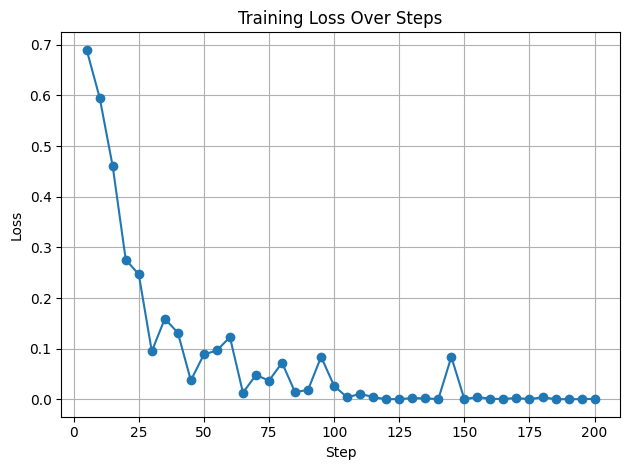

In [ ]:
import matplotlib.pyplot as plt

# Extract loss values
log_history = dpo_trainer.state.log_history
steps = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]

# Plot loss curve
plt.figure()
plt.plot(steps, losses, marker='o')
plt.title("Training Loss Over Steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"/content/drive/MyDrive/2_{new_model_id}_updated_loss_curve.png")
plt.show()
